# Notebook 2: Centrality and connectivity

Notebook 1 built the graph and hit a wall almost immediately: raw degree doesn't identify the nuclei I know to be anatomical convergence points. Nucleus ambiguus has degree 3 despite being shared by three separate cranial nerves, while CN III has degree 9 purely because oculomotor fans out to a lot of eye muscles. Degree counts *how many* connections, not *how important* — that's what this notebook is actually about.

This notebook is self-contained — it rebuilds the graph from scratch rather than depending on Notebook 1 having been run first. The construction is identical; see Notebook 1 for the reasoning behind each node and edge if you want the full walkthrough.

## Questions for this notebook

1. Is this graph even connected? I built it nerve by nerve — I never explicitly checked.
2. Which centrality measure actually captures "structurally important" here, given the graph is directed?
3. What role do the reflex/functional edges (VOR, corneal reflex, jaw jerk) actually play?
4. Does CN I and CN II's lack of a brainstem nucleus show up as a structural difference, as I predicted at the end of Notebook 1?

## Rebuilding the graph

Same construction as Notebook 1, condensed into fewer cells since the point of this notebook is what comes after.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

G = nx.DiGraph()

nerves = [
    ("CN I", "Olfactory", "special sensory"), ("CN II", "Optic", "special sensory"),
    ("CN III", "Oculomotor", "motor + parasympathetic"), ("CN IV", "Trochlear", "motor"),
    ("CN V", "Trigeminal", "mixed"), ("CN VI", "Abducens", "motor"),
    ("CN VII", "Facial", "mixed"), ("CN VIII", "Vestibulocochlear", "special sensory"),
    ("CN IX", "Glossopharyngeal", "mixed"), ("CN X", "Vagus", "mixed"),
    ("CN XI", "Accessory", "motor"), ("CN XII", "Hypoglossal", "motor"),
]
for nid, name, ftype in nerves:
    G.add_node(nid, label=name, kind="nerve", function=ftype)

nuclei = [
    "Olfactory bulb", "Lateral geniculate nucleus", "Oculomotor nucleus", "Edinger-Westphal nucleus",
    "Trochlear nucleus", "Main sensory nucleus V", "Spinal trigeminal nucleus", "Mesencephalic nucleus V",
    "Motor nucleus V", "Abducens nucleus", "Facial motor nucleus", "Superior salivatory nucleus",
    "Vestibular nuclei", "Cochlear nuclei", "Nucleus ambiguus", "Inferior salivatory nucleus",
    "Dorsal motor nucleus of vagus", "Nucleus of solitary tract", "Spinal accessory nucleus", "Hypoglossal nucleus",
]
for n in nuclei:
    G.add_node(n, kind="nucleus")

targets = [
    "Olfactory epithelium", "Retina", "Visual cortex", "Superior rectus", "Inferior rectus", "Medial rectus",
    "Inferior oblique", "Levator palpebrae superioris", "Ciliary muscle", "Sphincter pupillae", "Superior oblique",
    "Masseter/temporalis/pterygoids", "Face (V1/V2/V3 sensory territory)", "Lateral rectus",
    "Muscles of facial expression", "Lacrimal gland", "Submandibular/sublingual glands",
    "Anterior 2/3 tongue (taste)", "Cochlea (hearing)", "Vestibular apparatus (balance)", "Stylopharyngeus",
    "Parotid gland", "Posterior 1/3 tongue (taste)", "Carotid body/sinus", "Pharynx/larynx muscles",
    "Thoracic/abdominal viscera", "Epiglottis (taste)", "Sternocleidomastoid", "Trapezius", "Tongue musculature",
]
for t in targets:
    G.add_node(t, kind="target")

len(nerves), len(nuclei), len(targets)

(12, 20, 30)

In [2]:
edges = [
    ("CN I", "Olfactory epithelium", "afferent"), ("Olfactory epithelium", "Olfactory bulb", "afferent"),
    ("CN II", "Retina", "afferent"), ("Retina", "Lateral geniculate nucleus", "afferent"),
    ("Lateral geniculate nucleus", "Visual cortex", "afferent"),

    ("Oculomotor nucleus", "CN III", "efferent"), ("CN III", "Superior rectus", "efferent"),
    ("CN III", "Inferior rectus", "efferent"), ("CN III", "Medial rectus", "efferent"),
    ("CN III", "Inferior oblique", "efferent"), ("CN III", "Levator palpebrae superioris", "efferent"),
    ("Edinger-Westphal nucleus", "CN III", "efferent"), ("CN III", "Ciliary muscle", "efferent (parasympathetic)"),
    ("CN III", "Sphincter pupillae", "efferent (parasympathetic)"),

    ("Trochlear nucleus", "CN IV", "efferent"), ("CN IV", "Superior oblique", "efferent"),

    ("Face (V1/V2/V3 sensory territory)", "Main sensory nucleus V", "afferent"),
    ("Face (V1/V2/V3 sensory territory)", "Spinal trigeminal nucleus", "afferent"),
    ("Masseter/temporalis/pterygoids", "Mesencephalic nucleus V", "afferent (proprioceptive)"),
    ("Motor nucleus V", "CN V", "efferent"), ("CN V", "Masseter/temporalis/pterygoids", "efferent"),

    ("Abducens nucleus", "CN VI", "efferent"), ("CN VI", "Lateral rectus", "efferent"),

    ("Facial motor nucleus", "CN VII", "efferent"), ("CN VII", "Muscles of facial expression", "efferent"),
    ("Superior salivatory nucleus", "CN VII", "efferent"), ("CN VII", "Lacrimal gland", "efferent (parasympathetic)"),
    ("CN VII", "Submandibular/sublingual glands", "efferent (parasympathetic)"),
    ("Anterior 2/3 tongue (taste)", "Nucleus of solitary tract", "afferent"), ("CN VII", "Anterior 2/3 tongue (taste)", "afferent"),

    ("CN VIII", "Cochlea (hearing)", "afferent"), ("Cochlea (hearing)", "Cochlear nuclei", "afferent"),
    ("CN VIII", "Vestibular apparatus (balance)", "afferent"), ("Vestibular apparatus (balance)", "Vestibular nuclei", "afferent"),

    ("Nucleus ambiguus", "CN IX", "efferent"), ("CN IX", "Stylopharyngeus", "efferent"),
    ("Inferior salivatory nucleus", "CN IX", "efferent"), ("CN IX", "Parotid gland", "efferent (parasympathetic)"),
    ("Posterior 1/3 tongue (taste)", "Nucleus of solitary tract", "afferent"), ("CN IX", "Posterior 1/3 tongue (taste)", "afferent"),
    ("Carotid body/sinus", "CN IX", "afferent"),

    ("Nucleus ambiguus", "CN X", "efferent"), ("CN X", "Pharynx/larynx muscles", "efferent"),
    ("Dorsal motor nucleus of vagus", "CN X", "efferent"), ("CN X", "Thoracic/abdominal viscera", "efferent (parasympathetic)"),
    ("Epiglottis (taste)", "Nucleus of solitary tract", "afferent"), ("CN X", "Epiglottis (taste)", "afferent"),

    ("Spinal accessory nucleus", "CN XI", "efferent"), ("Nucleus ambiguus", "CN XI", "efferent (cranial root)"),
    ("CN XI", "Sternocleidomastoid", "efferent"), ("CN XI", "Trapezius", "efferent"),

    ("Hypoglossal nucleus", "CN XII", "efferent"), ("CN XII", "Tongue musculature", "efferent"),

    # Functional / reflex links between nuclei
    ("Vestibular nuclei", "Oculomotor nucleus", "functional (VOR)"),
    ("Vestibular nuclei", "Trochlear nucleus", "functional (VOR)"),
    ("Vestibular nuclei", "Abducens nucleus", "functional (VOR)"),
    ("Spinal trigeminal nucleus", "Facial motor nucleus", "functional (corneal reflex)"),
    ("Mesencephalic nucleus V", "Motor nucleus V", "functional (jaw jerk)"),
]

for u, v, kind in edges:
    G.add_edge(u, v, kind=kind)

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Nodes: 62, Edges: 58


## Question 1: Is this thing even connected?

I never actually checked this in Notebook 1 — I was building nerve-by-nerve and assumed it would hang together as one structure. "Weakly connected" for a directed graph means connected if you ignore edge direction — the loosest possible test.

In [3]:
print("Weakly connected:", nx.is_weakly_connected(G))
print("Number of weakly connected components:", nx.number_weakly_connected_components(G))

nerve_kind = lambda n: G.nodes[n].get("kind")
for i, comp in enumerate(sorted(nx.weakly_connected_components(G), key=len, reverse=True), 1):
    nerves_in_comp = sorted([n for n in comp if nerve_kind(n) == "nerve"])
    print(f"Component {i} ({len(comp)} nodes): {nerves_in_comp}")

Weakly connected: False
Number of weakly connected components: 6
Component 1 (27 nodes): ['CN IX', 'CN VII', 'CN X', 'CN XI']
Component 2 (21 nodes): ['CN III', 'CN IV', 'CN VI', 'CN VIII']
Component 3 (4 nodes): ['CN II']
Component 4 (4 nodes): ['CN V']
Component 5 (3 nodes): ['CN I']
Component 6 (3 nodes): ['CN XII']


Not connected at all — six separate components. That's a genuine surprise, and worth sitting with rather than rushing past.

Looking at which nerves land in which component, the pattern makes complete sense once I see it:

- **CN I, CN II, CN V, CN XII** each sit in their own tiny, isolated component. No cross-links to anything else.
- **CN III, IV, VI, VIII** cluster together — held together entirely by the vestibulo-ocular reflex edges I added.
- **CN VII, IX, X, XI** cluster together — held together by the shared nucleus ambiguus, nucleus of solitary tract, and spinal trigeminal nucleus, plus the corneal reflex link.

In other words: without the handful of reflex/convergence links I added on top of the basic nerve→nucleus→target structure, this graph would be **twelve separate stars**, one per nerve, with no relationship between them at all. The cranial nerves don't form a connected system by default — they form one *because of* a small number of specific physiological wiring facts (shared nuclei, reflex arcs). That's not something I set out to demonstrate; it just fell out of building the graph honestly and checking.

It also means CN I, II, V, and XII are structurally isolated in this model — not because they're unimportant, but because I haven't included any reflex or shared-nucleus link that happens to involve them. That's a limitation of what I chose to encode in v1, not a claim about the real nervous system (V in particular has plenty of real connections — it's central to both the corneal reflex and jaw jerk, which I did include, but those didn't happen to bridge it to another *nerve's* component — the jaw jerk is self-contained within V, and the corneal reflex link I added goes spinal trigeminal → facial motor nucleus, which is one node inside V's neighbourhood but the edge itself sits in the VII/IX/X component rather than pulling V's whole subgraph in). Worth revisiting if I extend the reflex set later.

## Question 2: Which centrality measure is right here?

Degree already failed to find the convergence points. Betweenness centrality — how often a node sits on the shortest path between other pairs of nodes — should be more sensitive to genuine "convergence point" structure. Let's try it directed first, since that's how I actually built the edges.

In [4]:
bc_directed = nx.betweenness_centrality(G)
print("Top 10 betweenness (directed):")
for n, v in sorted(bc_directed.items(), key=lambda x: -x[1])[:10]:
    print(f"  {n}: {v:.4f}")

Top 10 betweenness (directed):
  CN III: 0.0096
  Vestibular nuclei: 0.0082
  Oculomotor nucleus: 0.0066
  CN VII: 0.0055
  Vestibular apparatus (balance): 0.0044
  Facial motor nucleus: 0.0033
  CN IX: 0.0031
  CN X: 0.0020
  Spinal trigeminal nucleus: 0.0019
  Trochlear nucleus: 0.0016


Better than degree, but still not quite what the anatomy would predict — nucleus ambiguus and nucleus of solitary tract don't make the top 10, even though I know they're real convergence points for three nerves each.

The reason is the directionality itself. I split every connection into afferent or efferent, which means information only flows one way through each nucleus in the graph — into it from a sensory target, or out of it to a nerve. There's no directed path that goes *through* nucleus ambiguus from, say, a target of CN IX to a target of CN X, because CN IX and CN X's targets don't feed into each other via the nucleus in the direction the edges point. The directed structure is anatomically accurate (that genuinely is how the reflex arc works — signal goes in one door and out another), but it under-counts nucleus ambiguus's importance for a *structural* question like "how many different nerves depend on this one node."

For the structural question — as opposed to a "how does a signal actually propagate" question — it makes sense to ignore direction and ask which nodes sit on the most shortest paths regardless of which way the arrows point.

In [5]:
UG = G.to_undirected()
bc_undirected = nx.betweenness_centrality(UG)
print("Top 10 betweenness (undirected):")
for n, v in sorted(bc_undirected.items(), key=lambda x: -x[1])[:10]:
    print(f"  {n}: {v:.4f}")

Top 10 betweenness (undirected):
  CN VII: 0.0907
  Nucleus of solitary tract: 0.0904
  Anterior 2/3 tongue (taste): 0.0836
  Vestibular nuclei: 0.0727
  CN IX: 0.0702
  CN III: 0.0678
  Nucleus ambiguus: 0.0615
  CN X: 0.0585
  Oculomotor nucleus: 0.0541
  Posterior 1/3 tongue (taste): 0.0464


That's much closer to what I expected going in. Nucleus of solitary tract and nucleus ambiguus are both in the top 10, alongside CN VII, CN IX, CN III — the nerves I'd already flagged as heavily connected. This isn't me tuning the analysis to get the answer I wanted; it's the same graph, same data, just asking "how many shortest paths pass through this node" without caring which direction the arrows point.

The honest takeaway: **the right centrality measure depends on the question, and "direction" is a modelling choice, not just a technical detail.** Directed betweenness answers "how much does this node control the actual flow of a nerve signal." Undirected betweenness answers "how structurally load-bearing is this node if you don't care about signal direction." Both are legitimate — they're just different questions, and I got the wrong answer initially because I hadn't been explicit about which one I was asking.

## Eigenvector centrality — a dead end worth showing

Eigenvector centrality scores a node highly if it's connected to other highly-scored nodes. It's the basis of PageRank, and it's a natural thing to try here. Worth trying, worth showing why it doesn't work.

In [6]:
try:
    ec = nx.eigenvector_centrality(G, max_iter=1000)
    print("Top 10 eigenvector (directed):")
    for n, v in sorted(ec.items(), key=lambda x: -x[1])[:10]:
        print(f"  {n}: {v:.4f}")
except nx.PowerIterationFailedConvergence as e:
    print("Failed to converge:", e)

Top 10 eigenvector (directed):
  CN V: 0.5000
  Mesencephalic nucleus V: 0.5000
  Motor nucleus V: 0.5000
  Masseter/temporalis/pterygoids: 0.5000
  Nucleus of solitary tract: 0.0000
  Superior rectus: 0.0000
  Inferior rectus: 0.0000
  Medial rectus: 0.0000
  Inferior oblique: 0.0000
  Levator palpebrae superioris: 0.0000


It "worked" in the sense that it didn't crash, but the result is useless — it gives four nodes a score of exactly 0.5 (CN V's tiny isolated four-node component) and every other node in the graph a score of 0.0.

This is a real limitation of the measure on this graph, not a bug. Eigenvector centrality on a directed graph relies on the graph being strongly connected for the underlying linear algebra (Perron-Frobenius) to give a meaningful answer across the whole structure. This graph is not just weakly disconnected (six components, established above) — most of those components aren't even strongly connected internally, since so many edges only run one direction. NetworkX's power iteration just converges on whichever isolated pocket happens to dominate numerically, which here is an arbitrary four-node island rather than anything anatomically meaningful.

Lesson: eigenvector centrality (and PageRank, which has the same requirement) isn't the right tool for a small, direction-heavy, disconnected graph like this one. Betweenness and closeness both tolerate disconnection far better — they simply treat unreachable pairs as having no path, rather than breaking down entirely. Dropping eigenvector centrality here rather than forcing a result out of it.

## Closeness centrality — and which direction it's measuring

Closeness centrality asks how close a node is, on average, to every other node it can reach. On a directed graph this splits into two genuinely different questions depending on which way you measure distance: "how quickly can everything reach *this* node" versus "how quickly can *this* node reach everything else." NetworkX's default (`closeness_centrality(G)`) measures the first — incoming distance.

In [7]:
cc_incoming = nx.closeness_centrality(G)
print("Top 5 closeness — incoming (how reachable this node is):")
for n, v in sorted(cc_incoming.items(), key=lambda x: -x[1])[:5]:
    print(f"  {n}: {v:.4f}")

cc_outgoing = nx.closeness_centrality(G.reverse())
print("\nTop 5 closeness — outgoing (how much this node can reach):")
for n, v in sorted(cc_outgoing.items(), key=lambda x: -x[1])[:5]:
    print(f"  {n}: {v:.4f}")

Top 5 closeness — incoming (how reachable this node is):
  Nucleus of solitary tract: 0.0893
  CN IX: 0.0492
  CN VII: 0.0375
  Stylopharyngeus: 0.0375
  Parotid gland: 0.0375

Top 5 closeness — outgoing (how much this node can reach):
  CN III: 0.1148
  Nucleus ambiguus: 0.1073
  Vestibular nuclei: 0.1025
  CN VIII: 0.0822
  Vestibular apparatus (balance): 0.0807


Nucleus of solitary tract tops the incoming list — makes sense, it's the single node that taste and visceral sensory afferents from three different nerves (VII, IX, X) all converge on. It's easy to reach *from* a lot of places because a lot of places feed directly into it.

CN III tops the outgoing list, followed by nucleus ambiguus and vestibular nuclei — these are the nodes that can reach the most other nodes quickly, which fits: CN III fans out to many downstream targets, and nucleus ambiguus/vestibular nuclei sit upstream of several nerves each.

Two different, both legitimate, both telling a slightly different part of the same anatomical story.

## Question 3: What do the reflex edges actually do?

Section 1 showed the six components exist *because* the reflex/shared-nucleus edges are the only thing linking otherwise-separate nerve subsystems. Let's make that concrete with a specific pair: CN VIII (balance) and CN III (eye movement) — linked by the vestibulo-ocular reflex, which is what keeps your gaze stable when you turn your head.

In [8]:
print("CN VIII to CN III, with the VOR edge present:")
print(" ", nx.shortest_path(G, "CN VIII", "CN III"))

G_no_reflex = G.copy()
functional_edges = [(u, v) for u, v, d in G.edges(data=True) if "functional" in d["kind"]]
G_no_reflex.remove_edges_from(functional_edges)

print("\nRemoved reflex edges:", functional_edges)
print("\nCN VIII to CN III, without them:")
try:
    print(" ", nx.shortest_path(G_no_reflex.to_undirected(), "CN VIII", "CN III"))
except nx.NetworkXNoPath:
    print("  No path exists.")

CN VIII to CN III, with the VOR edge present:
  ['CN VIII', 'Vestibular apparatus (balance)', 'Vestibular nuclei', 'Oculomotor nucleus', 'CN III']

Removed reflex edges: [('Spinal trigeminal nucleus', 'Facial motor nucleus'), ('Mesencephalic nucleus V', 'Motor nucleus V'), ('Vestibular nuclei', 'Oculomotor nucleus'), ('Vestibular nuclei', 'Trochlear nucleus'), ('Vestibular nuclei', 'Abducens nucleus')]

CN VIII to CN III, without them:
  No path exists.


No path at all, once the reflex edges are gone — not just a longer path, a completely disconnected one. Which is a nice, concrete way of stating what "the VOR links the vestibular and oculomotor systems" actually means in graph terms: it isn't decoration on top of an otherwise-connected structure, it's the *entire* connection between those two nerve subsystems, in this model. Take it away and CN VIII and CN III have nothing to do with each other.

## Question 4: Are CN I and CN II structurally different, as predicted?

Notebook 1 flagged this as worth checking — I and II don't route through a brainstem nucleus the way III–XII do, so I expected them to look different structurally.

In [9]:
for n in ["CN I", "CN II", "CN III", "CN VII"]:
    print(f"{n}: in-degree {G.in_degree(n)}, out-degree {G.out_degree(n)}")

CN I: in-degree 0, out-degree 1
CN II: in-degree 0, out-degree 1
CN III: in-degree 2, out-degree 7
CN VII: in-degree 2, out-degree 4


Confirmed, and cleanly: CN I and CN II both have **in-degree zero**. Nothing feeds into them in this graph — they're pure sources, sitting at the very top of their own tiny, isolated component, sending signal onward but never receiving any. Every other nerve has at least one incoming edge, whether from a motor nucleus driving it (CN III, in-degree 2) or from the sensory periphery feeding into it directly alongside a nucleus (CN VII, in-degree 1).

That's exactly the structural signature I'd expect from nerves that don't pass through a shared brainstem relay — and it fell straight out of a two-line degree check, once I knew what to look for.

## Visualising the components

Colouring by weakly connected component makes the fragmentation from Question 1 immediately visible — six clearly separate clusters, no crossover, exactly as the numbers said.

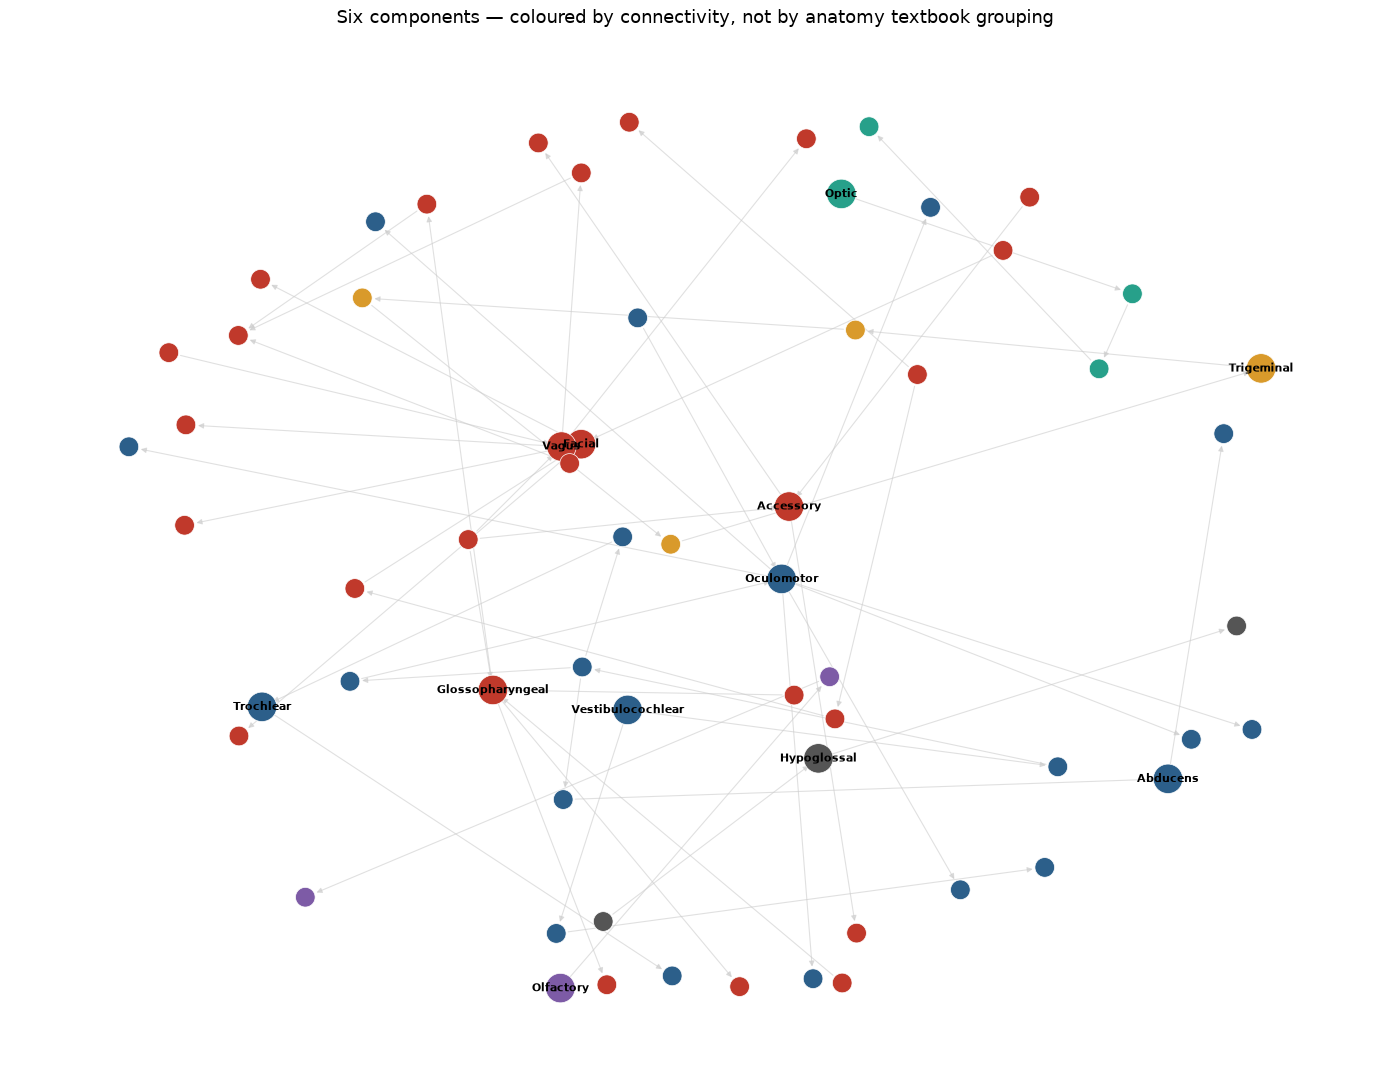

In [10]:
components = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
component_id = {}
for i, comp in enumerate(components):
    for n in comp:
        component_id[n] = i

palette = ["#c0392b", "#2c5f8a", "#27a08a", "#d99a2b", "#7d5ba6", "#555555"]
node_colors = [palette[component_id[n] % len(palette)] for n in G.nodes]
node_sizes = [450 if G.nodes[n]["kind"] == "nerve" else 200 for n in G.nodes]

pos = nx.spring_layout(G, seed=11, k=0.7)

fig, ax = plt.subplots(figsize=(14, 11))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#cccccc", arrows=True,
                        arrowsize=8, width=0.8, alpha=0.6)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                        edgecolors="white", linewidths=0.5)

nerve_labels = {n: G.nodes[n]["label"] for n in G.nodes if G.nodes[n]["kind"] == "nerve"}
nx.draw_networkx_labels(G, pos, labels=nerve_labels, ax=ax, font_size=8, font_weight="bold")

ax.set_title("Six components — coloured by connectivity, not by anatomy textbook grouping", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("cranial_nerve_components.png", dpi=150, facecolor="white")
plt.show()

## Where this leaves things

Four honest findings, none of which I set out to manufacture:

1. **The graph isn't connected** — it's six separate components, held together only by the handful of reflex/shared-nucleus edges I added on top of the basic nerve structure.
2. **Directed betweenness undercounts the convergence nuclei**; undirected betweenness recovers them. Direction is a real modelling choice, not just a technicality — it changes which question you're actually asking.
3. **Eigenvector centrality is the wrong tool here** — it needs strong connectivity to mean anything, and this graph doesn't have it. Worth knowing when *not* to reach for a measure, not just how to compute it.
4. **CN I and CN II really are structurally distinct** — zero in-degree, confirming the Notebook 1 prediction cleanly.

### Things to try (Notebook 3 and beyond)

- Compare this fragmentation pattern against a real structural connectome — is "mostly isolated subsystems held together by a few critical links" a general feature of brain networks at any scale, or an artefact of how coarsely I've encoded this one?
- Add the reflexes left out of v1 (gag reflex, pupillary light reflex) and see whether they merge any of the six components — the pupillary light reflex in particular links CN II (currently isolated) to CN III's component via the pretectal nucleus, which would be a good test of the "only reflexes connect subsystems" claim
- Try a weighted version where reflex edges get a different weight than direct afferent/efferent edges, and see how that changes betweenness rankings
- Formalise the "removing an edge disconnects the graph" observation from Question 3 as an actual bridge/cut-edge analysis across the whole graph, rather than checking one pair by hand